# Phần 1 - Bài toán Hồi quy (Regression)


In [12]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from utils import drop_high_missing_columns

In [3]:
# Đường dẫn tương đối của file dữ liệu
path = "../../data/vietnam_housing_dataset.csv"

In [21]:
if os.path.exists(path):
    data = pd.read_csv(path)
    print("Đọc file thành công!")
    display(data.head())
else:
    print(f"Không tìm thấy file tại: {os.path.abspath(path)}")

Đọc file thành công!


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90


## 1. Phân tích và tiền xử lý
### a. Phân tích và khám phá (EDA)
- Thông kê mô tả

In [22]:
data.describe()

,Area,Frontage,Access Road,Floors,Bedrooms,Bathrooms,Price
count,30229.000000,18665.000000,16932.000000,26626.000000,25067.000000,23155.000000,30229.000000
mean,68.498741,5.361692,7.853800,3.410426,3.511030,3.346837,5.872078
std,48.069835,4.346174,7.451313,1.328897,1.309116,1.400181,2.211877
min,3.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,40.000000,4.000000,4.000000,2.000000,3.000000,2.000000,4.200000
50%,56.000000,4.500000,6.000000,3.000000,3.000000,3.000000,5.900000
75%,80.000000,5.000000,10.000000,4.000000,4.000000,4.000000,7.500000
max,595.000000,77.000000,85.000000,10.000000,9.000000,9.000000,11.500000


- Loại bỏ những cột có quá nhiều giá trị null (>50%)

In [23]:
missing_value = data.isnull().sum()
print('Số lượng giá trị thiếu trong mỗi cột: ')
print(missing_value[missing_value > 0])
data = drop_high_missing_columns(data,0.5)

Số lượng giá trị thiếu trong mỗi cột: 
Frontage             11564
Access Road          13297
House direction      21239
Balcony direction    24983
Floors                3603
Bedrooms              5162
Bathrooms             7074
Legal status          4506
Furniture state      14119
dtype: int64
Đã loại bỏ các cột sau (> 50.0% missing):
 - House direction: 70.26%
 - Balcony direction: 82.65%


- Phân bố của biến mục tiêu

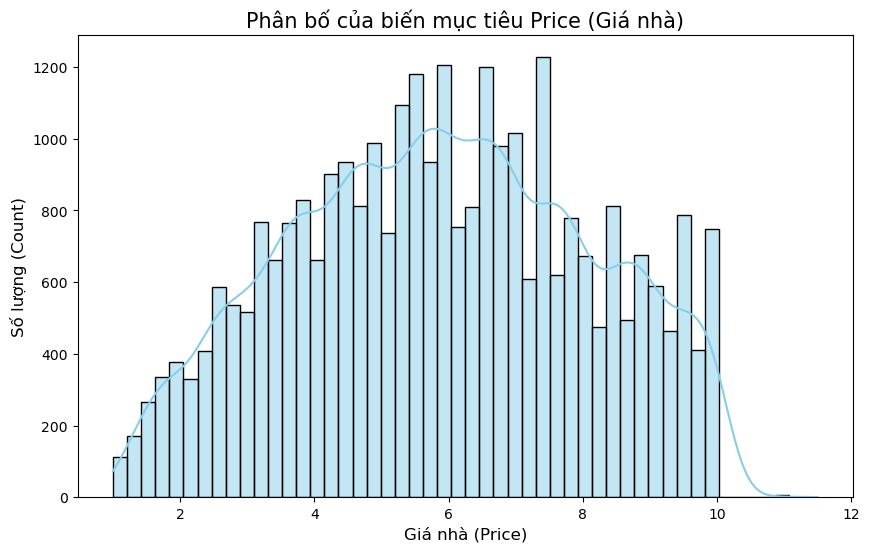

In [24]:
# Thiết lập kích thước
plt.figure(figsize=(10, 6))

# Vẽ Histogram
sns.histplot(data['Price'], kde=True, color='skyblue')

# Thêm tiêu đề và nhãn theo quy định đồ án 
plt.title('Phân bố của biến mục tiêu Price (Giá nhà)', fontsize=15)
plt.xlabel('Giá nhà (Price)', fontsize=12)
plt.ylabel('Số lượng (Count)', fontsize=12)

# Hiển thị
plt.show()

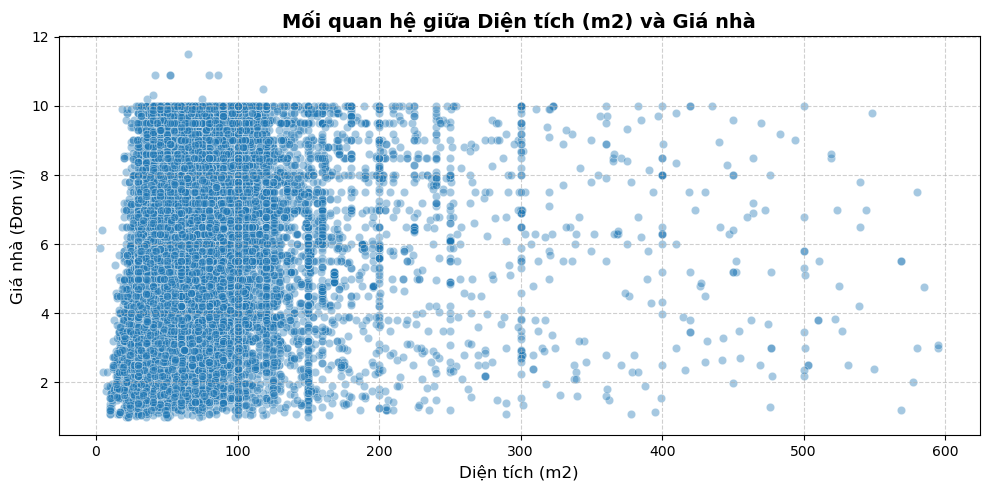

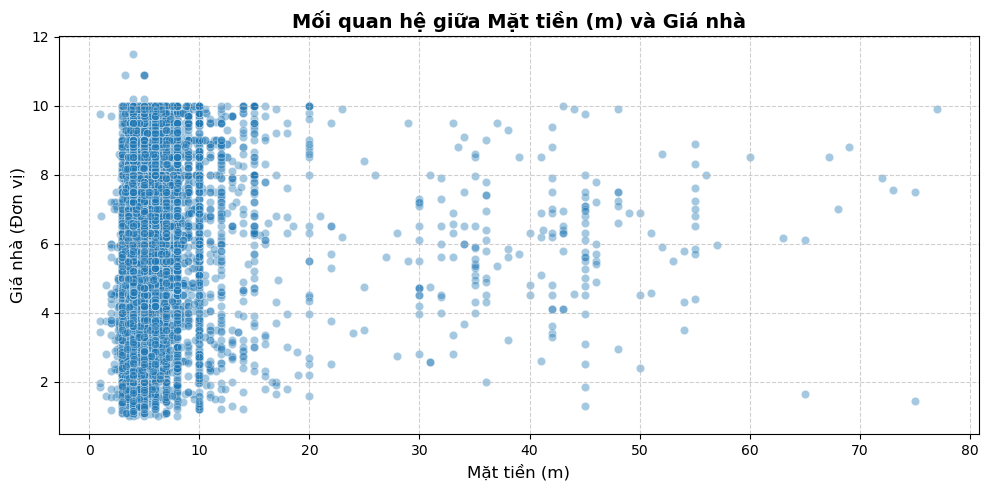

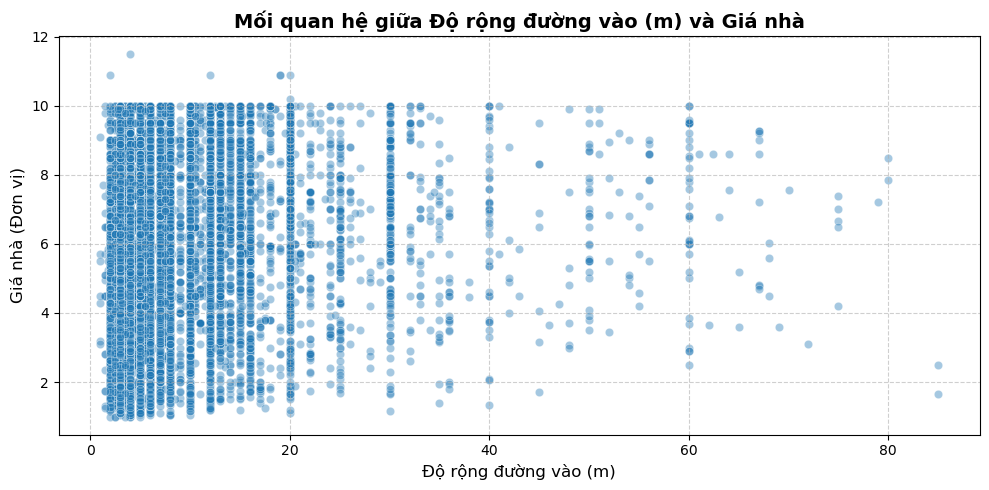

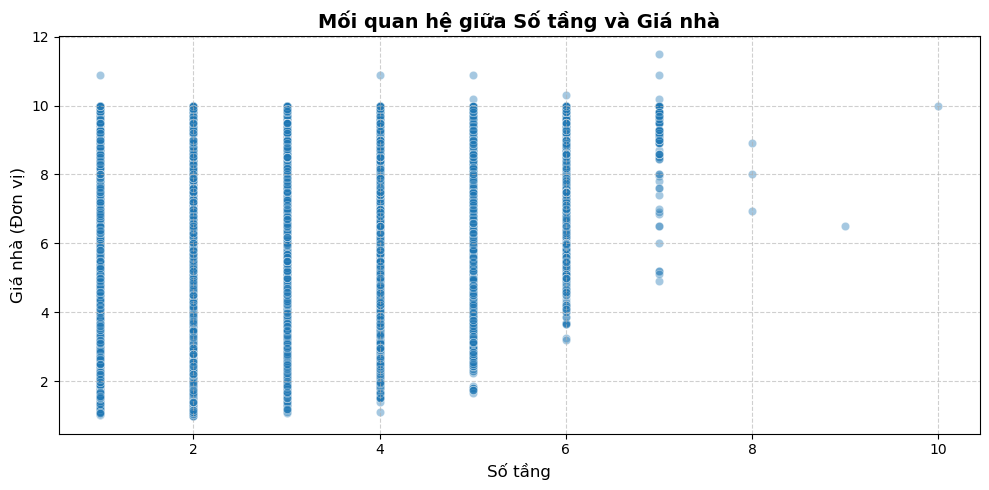

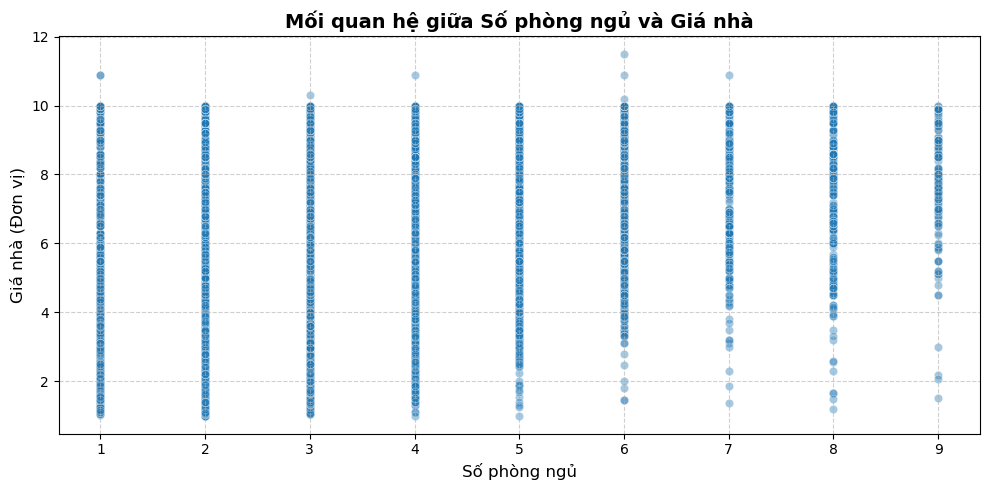

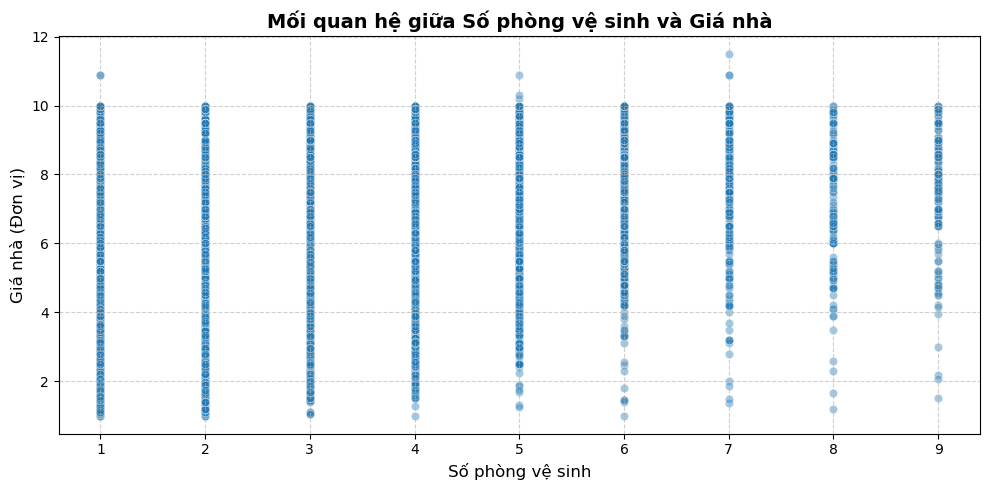

In [27]:
# 1. Tạo từ điển để dịch tên các đặc trưng (tùy chỉnh theo cột trong file CSV của bạn)
name_mapping = {
    'Area': 'Diện tích (m2)',
    'Floors': 'Số tầng',
    'Bedrooms': 'Số phòng ngủ',
    'Bathrooms': 'Số phòng vệ sinh',
    'Frontage': 'Mặt tiền (m)',
    'Access Road': 'Độ rộng đường vào (m)',
    'Price': 'Giá nhà'
}

# 2. Lấy danh sách các đặc trưng số
numerical_features = data.select_dtypes(include=['int64', 'float64']).columns
numerical_features = numerical_features.drop('Price', errors='ignore')

# 3. Vẽ biểu đồ scatter cho từng đặc trưng
for feature in numerical_features:
    # Lấy tên tiếng Việt từ mapping, nếu không có thì dùng tên gốc
    feature_vn = name_mapping.get(feature, feature)
    price_vn = name_mapping.get('Price', 'Giá')
    
    plt.figure(figsize=(10, 5))
    
    # Vẽ scatter plot với màu sắc chuyên nghiệp hơn
    sns.scatterplot(data=data, x=feature, y='Price', alpha=0.4)
    
    # Việt hóa các tiêu đề và nhãn theo yêu cầu mục 2.2.2 
    plt.title(f'Mối quan hệ giữa {feature_vn} và {price_vn}', fontsize=14, fontweight='bold')
    plt.xlabel(feature_vn, fontsize=12)
    plt.ylabel(f'{price_vn} (Đơn vị)', fontsize=12)
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()